# T-Test - Complete Practice Notebook

**What is T-Test?**
T-Test is a statistical test used to compare means
when the sample size is small (n < 30) or when the
population standard deviation is unknown.

**When to use T-Test?**
- Sample size is small (n < 30)
- Population standard deviation is unknown
- Data is approximately normally distributed

**Types of T-Test:**
- One Sample T-Test       → Compare sample mean with a known value
- Independent (Two Sample) T-Test → Compare means of two different groups
- Paired T-Test            → Compare means of the same group before/after

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1. Theory

**Hypothesis:**
- H0 (Null Hypothesis)      → There is NO significant difference
- H1 (Alternate Hypothesis) → There IS a significant difference

**T-Score Formula (One Sample):**
t = (X̄ - μ) / (s / √n)

Where:
- X̄ = Sample Mean
- μ  = Population Mean
- s  = Sample Standard Deviation
- n  = Sample Size

**Degrees of Freedom:**
df = n - 1

**Decision Rule:**
- If p-value < 0.05 → Reject H0 → Significant difference exists
- If p-value > 0.05 → Accept H0 → No significant difference

## 2. One Sample T-Test

**Question:**
A coaching institute claims their students score an
average of 75 marks. We took a small sample of 10
students. Is our sample mean significantly different
from 75?

**H0:** Sample mean = 75
**H1:** Sample mean ≠ 75

In [4]:
# Self made dataset → marks of 10 students
sample_marks = np.array([72, 88, 85, 60, 90, 78, 55, 82, 65, 91])

population_mean = 75

print(f"Sample : {sample_marks}")
print(f"Sample Size : {len(sample_marks)}")
print(f"Sample Mean : {np.mean(sample_marks):.2f}")
print(f"Sample Std Dev : {np.std(sample_marks, ddof=1)}")
print(f"Population Mean : {population_mean}")

Sample : [72 88 85 60 90 78 55 82 65 91]
Sample Size : 10
Sample Mean : 76.60
Sample Std Dev : 12.980326994682718
Population Mean : 75


In [5]:
# Manual T-Score Calculation

sample_mean = np.mean(sample_marks)
sample_std = np.std(sample_marks, ddof=1)
sample_size = len(sample_marks)

t_score = (sample_mean - population_mean) / (sample_std / np.sqrt(sample_size))
df_val = sample_size - 1

print(f"T-Score : {t_score:.2f}")
print(f"Degrees of Freedom : {df_val}")
p_value = 2 * (1 -stats.t.cdf(abs(t_score),df_val))
print(f"P-Value : {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0")
else:
    print("Accept H0")

T-Score : 0.39
Degrees of Freedom : 9
P-Value : 0.7058
Accept H0


In [6]:
# using scipy library

t_score, p_value = stats.ttest_1samp(sample_marks, population_mean)

print(f"T-Score : {t_score:.2f}")
print(f"P-Value : {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0")
else:
    print("Accept H0")

T-Score : 0.39
P-Value : 0.7058
Accept H0


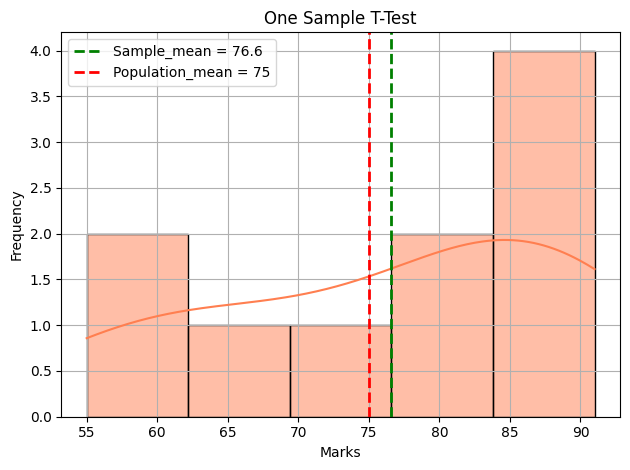

In [8]:
# Visualization

sns.histplot(sample_marks, bins = 5, color = 'coral', kde = True)
plt.axvline(sample_mean, color = 'green', linestyle = 'dashed', linewidth = 2,
            label = f"Sample_mean = {sample_mean:.1f}")
plt.axvline(population_mean, color = 'red', linestyle = 'dashed', linewidth = 2,
            label = f"Population_mean = {population_mean}")
plt.title("One Sample T-Test")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

## 3. Independent T-Test

**Question:**
Are the marks of Male and Female students
significantly different?

**H0:** Mean of Male = Mean of Female
**H1:** Mean of Male ≠ Mean of Female

In [9]:
# Self made dataset
male_marks   = np.array([72, 88, 85, 60, 90, 78, 55, 82, 65, 91])
female_marks = np.array([65, 95, 80, 88, 92, 70, 85, 90, 78, 93])

print(f"Male   → Mean: {np.mean(male_marks):.2f},   Std: {np.std(male_marks, ddof=1):.2f},   N: {len(male_marks)}")
print(f"Female → Mean: {np.mean(female_marks):.2f}, Std: {np.std(female_marks, ddof=1):.2f}, N: {len(female_marks)}")

Male   → Mean: 76.60,   Std: 12.98,   N: 10
Female → Mean: 83.60, Std: 10.15, N: 10


## Assumption Check — Equal Variance (Levene's Test)

Independent T-Test assumes equal variance between groups.
We check this using Levene's Test.

- If p > 0.05 → Variances are equal → use standard T-Test
- If p < 0.05 → Variances are unequal → use Welch's T-Test

In [11]:
levene_stat, levene_p = stats.levene(male_marks, female_marks)

print(f"Levene's Statistic : {levene_stat:.4f}")
print(f"Levene's P-Value   : {levene_p:.4f}")

if(levene_p > 0.05):
    print("Variances are equal")
else:
    print("Variances are unequal")

Levene's Statistic : 0.6922
Levene's P-Value   : 0.4163
Variances are equal


In [12]:
t_stat , p_val = stats.ttest_ind(male_marks, female_marks, equal_var = True)

print(f"T-Score : {t_stat:.4f}")
print(f"P-Value : {p_val:.4f}")

if p_val < 0.05:
    print("Reject H0")
else:
    print("Accept H0")

T-Score : -1.3436
P-Value : 0.1958
Accept H0


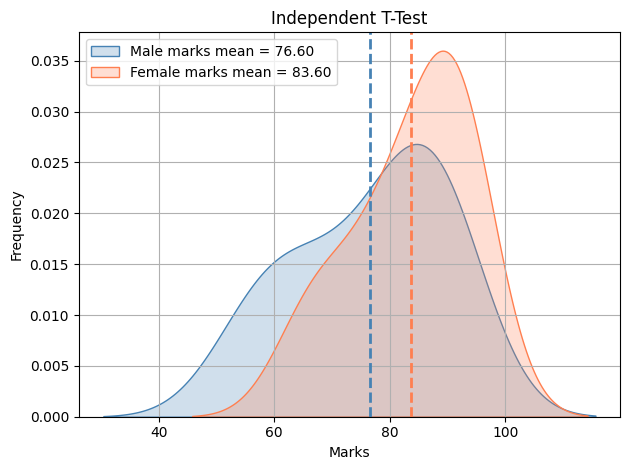

In [15]:
# visualization
sns.kdeplot(male_marks, fill = True, color = 'Steelblue',
            label = f'Male marks mean = {np.mean(male_marks):.2f}')
sns.kdeplot(female_marks,fill = True, color = 'coral',
            label = f'Female marks mean = {np.mean(female_marks):.2f}')
plt.axvline(np.mean(male_marks), color = 'Steelblue', linestyle = 'dashed', linewidth = 2)
plt.axvline(np.mean(female_marks), color = 'coral', linestyle = 'dashed', linewidth = 2)
plt.title("Independent T-Test")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

## 4. Paired T-Test

**Question:**
Did students' marks improve after attending
a special coaching session?
(Same students, Before vs After)

**H0:** Mean Before = Mean After
**H1:** Mean Before ≠ Mean After

In [16]:
# Self made dataset → same 10 students, before and after coaching
before_coaching = np.array([60, 65, 70, 55, 72, 68, 58, 75, 62, 70])
after_coaching  = np.array([68, 72, 75, 64, 78, 74, 66, 80, 70, 76])

print(f"Before → Mean: {np.mean(before_coaching):.2f}")
print(f"After  → Mean: {np.mean(after_coaching):.2f}")
print(f"Average Improvement: {np.mean(after_coaching - before_coaching):.2f}")

Before → Mean: 65.50
After  → Mean: 72.30
Average Improvement: 6.80


In [17]:
t_stat, p_val = stats.ttest_rel(before_coaching, after_coaching)

print(f"T-Score : {t_stat:.4f}")
print(f"P-Value : {p_val:.4f}")

if p_val < 0.05:
    print("Reject H0")
else:
    print("Accept H0")

T-Score : -15.3771
P-Value : 0.0000
Reject H0


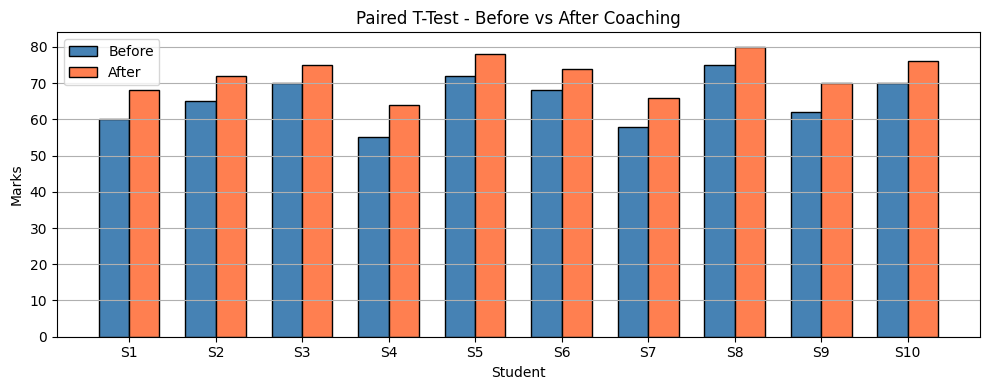

In [18]:
# Visualization

students = [f"S{i+1}" for i in range(10)]

plt.figure(figsize=(10, 4))

x = np.arange(len(students))
width = 0.35

plt.bar(x - width/2, before_coaching, width, label="Before", color="steelblue", edgecolor="black")
plt.bar(x + width/2, after_coaching,  width, label="After",  color="coral",     edgecolor="black")

plt.title("Paired T-Test - Before vs After Coaching")
plt.xlabel("Student")
plt.ylabel("Marks")
plt.xticks(x, students)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Conclusion

In this notebook I covered:

- What is T-Test and When to use it
- Hypothesis (H0 and H1)
- T-Score Formula and Degrees of Freedom
- One Sample T-Test (Self Made Dataset)
- Independent T-Test (Self Made Dataset) + Levene's Test
- Paired T-Test (Self Made Dataset)
- Visualizations